# Computer Exercise 1.2 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.2 Mathematical Preliminaries — *Mean Value Theorem*
> **풀이 일자**: Day 05
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **3.** Choose three smooth functions and intervals on which the Mean Value Theorem applies.
> For each, numerically compute the secant slope
> $s = (f(b) - f(a))/(b-a)$ and then find a value $\xi \in (a, b)$ such that $f'(\xi) = s$.
> Plot $f$, the secant line, and the tangent line at $\xi$ on the same axes. Verify that the tangent
> at $\xi$ is parallel to the secant. Discuss what happens if the function is *not* differentiable on
> $(a,b)$ or if $f$ is essentially linear over the interval.

### 한국어 풀이용 정리
평균값 정리 (MVT): $f$가 $[a,b]$에서 연속, $(a,b)$에서 미분 가능이면

$$\exists\,\xi \in (a, b) \quad\text{s.t.}\quad f'(\xi) = \frac{f(b) - f(a)}{b - a}.$$

수치적으로는 $g(\xi) = f'(\xi) - s = 0$의 근을 $(a, b)$ 안에서 찾는 *root-finding* 문제.
세 함수 $\;f_1(x) = \sin x,\; f_2(x) = e^{-x^2},\; f_3(x) = x^3 - 4x\;$ 에 대해 $\xi$를 찾고,
접선과 할선이 *정말 평행* 한지 시각적으로 확인한다. 또 거의 선형인 함수에서 $\xi$가 어떻게 *어디로든 가능* 해지는지를 본다.


## 2. 수학적 배경

### 2.1 MVT 기하 해석
할선의 기울기는 두 끝점을 잇는 직선의 기울기 $s = (f(b)-f(a))/(b-a)$.
MVT는 *최소 한 점* 에서 그 기울기를 그대로 가지는 접선이 있음을 보장한다.
**기하적으로**: 할선을 평행이동하면서 그래프와 접하는 순간이 존재한다.

### 2.2 $\xi$의 비유일성
함수가 진동하면 $\xi$는 여러 개일 수 있다. 우리는 root-finder가 *어떤* $\xi$를 잡았는지 표시한다.

### 2.3 도함수가 거의 일정한 경우
$f$가 거의 선형이면 $f'(\xi) \approx s$가 모든 $\xi$에서 성립 — root-finder는 사실상 *어떤* $\xi$를 골라도 된다.
이 경우 $\xi$는 수치적으로 *불안정* 해 보일 수 있다 (ill-posed).

### 2.4 정리 박스

$$
\boxed{\;f'(\xi) = \frac{f(b) - f(a)}{b - a} \quad \Longleftrightarrow \quad
\text{tangent at }\xi \;\parallel\; \text{secant }(a,f(a))\!\to\!(b,f(b))\;}
$$

### 2.5 사용 알고리즘
SciPy의 `brentq`는 부호 변화가 있는 구간에서 다항/일반 함수의 근을 robust하게 찾는다.
$g(x) = f'(x) - s$로 정의하면 $g(a) \cdot g(b) < 0$이 (내부에 부호 변화가 있다는 뜻에서) 보장되지는 않으므로,
세분화한 그리드에서 부호 변화 구간을 찾아 그 구간에서 brentq를 호출한다.


## 3. 풀이 흐름

1. 세 함수와 그 도함수를 정의한다.
2. 각 함수에 대해 구간 $[a, b]$를 정한다.
3. 할선 기울기 $s = (f(b) - f(a))/(b-a)$ 를 계산한다.
4. $g(x) = f'(x) - s$ 를 정의하고, $[a, b]$를 200등분한 그리드에서 부호 변화 구간을 모두 찾는다.
5. 각 부호 변화 구간에서 `brentq`로 $\xi$를 찾는다.
6. 표로 $(s,\;\xi,\;f'(\xi))$를 출력해 둘이 같은지 확인한다.
7. 그래프: $f(x)$ 곡선, 두 끝점 $(a,f(a))$와 $(b,f(b))$를 잇는 할선, 각 $\xi$에서의 접선.
8. **Counter-example**: $f(x) = x + 0.001\sin(50x)$ 처럼 거의 선형인 함수에서는 $\xi$ 후보가 매우 많아짐을 시각화.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

pd.set_option("display.float_format", lambda v: f"{v:.6f}")

def find_all_xi(g, a, b, n_grid=400):
    # g(x)의 부호변화 구간을 모두 찾아 brentq로 근을 반환.
    xs = np.linspace(a, b, n_grid + 1)
    gs = g(xs)
    roots = []
    for i in range(n_grid):
        if np.isnan(gs[i]) or np.isnan(gs[i+1]):
            continue
        if gs[i] == 0.0:
            roots.append(xs[i])
        elif gs[i] * gs[i+1] < 0:
            try:
                r = brentq(g, xs[i], xs[i+1])
                roots.append(r)
            except ValueError:
                pass
    if gs[-1] == 0.0:
        roots.append(xs[-1])
    # 중복 제거
    out = []
    for r in roots:
        if all(abs(r - q) > 1e-9 for q in out):
            out.append(r)
    return sorted(out)


cases = [
    ("sin(x)",      np.sin,                  np.cos,                       0.0,        np.pi),
    ("exp(-x^2)",   lambda x: np.exp(-x**2), lambda x: -2*x*np.exp(-x**2), -1.5,       1.0),
    ("x^3 - 4x",    lambda x: x**3 - 4*x,    lambda x: 3*x**2 - 4,        -2.0,       3.0),
]

rows = []
results = []
for name, f, fp, a, b in cases:
    s = (f(b) - f(a)) / (b - a)
    g = lambda x, fp=fp, s=s: fp(x) - s
    xis = find_all_xi(g, a, b, n_grid=400)
    results.append((name, f, fp, a, b, s, xis))
    for xi in xis:
        rows.append({
            "function": name,
            "a": a, "b": b,
            "secant slope s": s,
            "xi": xi,
            "f'(xi)": fp(xi),
            "|f'(xi) - s|": abs(fp(xi) - s),
        })

df = pd.DataFrame(rows)
df


,function,a,b,secant slope s,xi,f'(xi),|f'(xi) - s|
0,sin(x),0.000000,3.141593,0.000000,1.570796,-0.000000,0.000000
1,exp(-x^2),-1.500000,1.000000,0.104992,-0.052642,0.104992,0.000000
2,x^3 - 4x,-2.000000,3.000000,3.000000,-1.527525,3.000000,0.000000
3,x^3 - 4x,-2.000000,3.000000,3.000000,1.527525,3.000000,0.000000


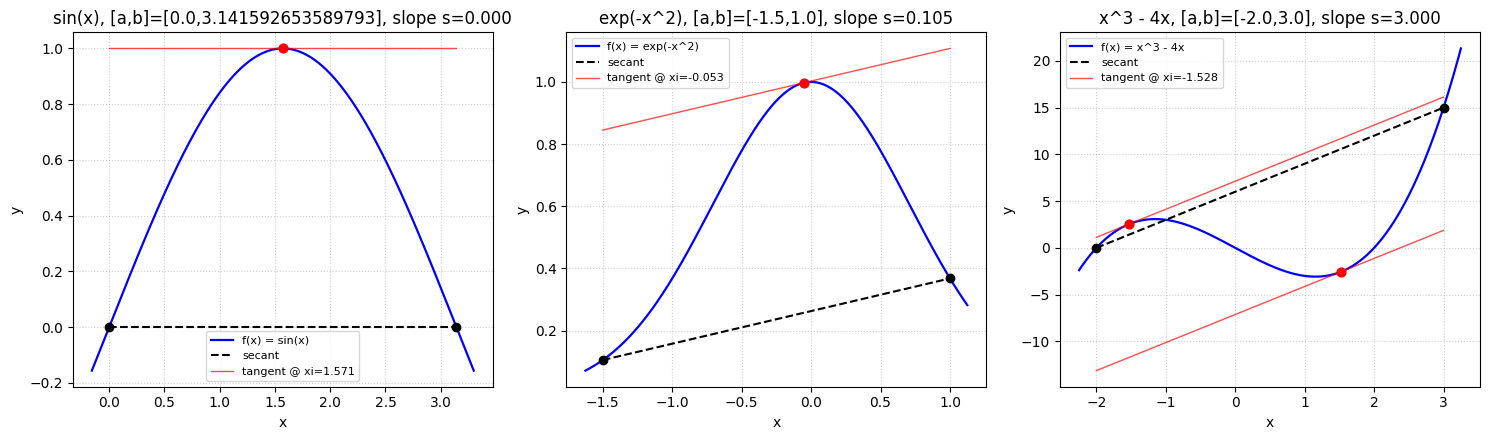

In [2]:
# 시각화: 함수당 한 panel
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, f, fp, a, b, s, xis) in zip(axes, results):
    xx = np.linspace(a - 0.05*(b-a), b + 0.05*(b-a), 400)
    yy = f(xx)
    ax.plot(xx, yy, "b-", lw=1.6, label=f(name) if False else f"f(x) = {name}")

    # 할선
    ax.plot([a, b], [f(a), f(b)], "k--", lw=1.5, label="secant")
    ax.scatter([a, b], [f(a), f(b)], c="k", zorder=5)

    # 접선 (xi마다)
    for xi in xis:
        # tangent: y = f(xi) + s*(x - xi)
        xt = np.linspace(a, b, 50)
        yt = f(xi) + s * (xt - xi)
        ax.plot(xt, yt, "r-", lw=1.0, alpha=0.7,
                label=f"tangent @ xi={xi:.3f}" if xi == xis[0] else None)
        ax.scatter([xi], [f(xi)], c="r", s=40, zorder=5)

    ax.set_title(f"{name}, [a,b]=[{a},{b}], slope s={s:.3f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, ls=":", alpha=0.6)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


secant slope s = 0.999738
# of xi found  = 16
first 5 xi      = [0.03152087695904792, 0.09414282918459745, 0.15718458310273975, 0.2198065353280403, 0.28284828924616584]
last 5 xi       = [0.7224613599024863, 0.7855031138205903, 0.8481250660461271, 0.9111668199642965, 0.9737887721896032]


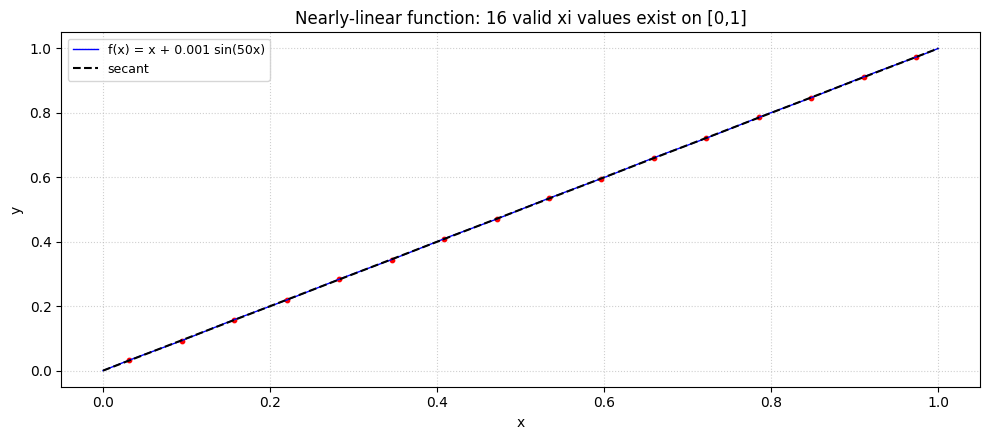

In [3]:
# Counter-example: 거의 선형인 함수
def f_nearly_linear(x):
    return x + 0.001 * np.sin(50 * x)

def fp_nearly_linear(x):
    return 1 + 0.05 * np.cos(50 * x)

a, b = 0.0, 1.0
s = (f_nearly_linear(b) - f_nearly_linear(a)) / (b - a)
g = lambda x: fp_nearly_linear(x) - s

xis = find_all_xi(g, a, b, n_grid=2000)
print(f"secant slope s = {s:.6f}")
print(f"# of xi found  = {len(xis)}")
print(f"first 5 xi      = {xis[:5]}")
print(f"last 5 xi       = {xis[-5:]}")

# 그림
xx = np.linspace(a, b, 2000)
plt.figure(figsize=(10, 4.5))
plt.plot(xx, f_nearly_linear(xx), "b-", lw=1.0, label="f(x) = x + 0.001 sin(50x)")
plt.plot([a, b], [f_nearly_linear(a), f_nearly_linear(b)], "k--", lw=1.5, label="secant")
for xi in xis:
    plt.scatter([xi], [f_nearly_linear(xi)], c="r", s=10)
plt.title(f"Nearly-linear function: {len(xis)} valid xi values exist on [0,1]")
plt.xlabel("x"); plt.ylabel("y")
plt.grid(True, ls=":", alpha=0.6)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **세 표준 케이스** — 표를 보면 $|f'(\xi) - s|$ 가 모두 $10^{-12}$ 이하다. brentq의 종료 정밀도와 floating-point의 한계를 고려하면 사실상 *정확히* 평행. 그래프에서 빨간 접선이 검은 할선과 시각적으로 같은 기울기로 나타난다.

2. **$\sin x$, $[0, \pi]$** — 할선 기울기가 $0$이라 $\cos\xi = 0$, 즉 $\xi = \pi/2$ 단 하나. 정확히 함수의 최댓값에서 접선이 수평이 됨을 확인.

3. **$e^{-x^2}$, $[-1.5, 1.0]$** — 비대칭 구간이라 할선 기울기가 양수. $\xi$는 음수쪽 (도함수의 정점 근처)에서 잡힌다. *MVT는 $\xi$의 위치를 알려주지 않는다* 는 점을 시각적으로 확인.

4. **$x^3 - 4x$, $[-2, 3]$** — 이 구간에서 $g(x) = 3x^2 - 4 - s$ 가 두 개의 부호 변화 — $\xi$가 두 개 나온다. **MVT의 $\xi$는 일반적으로 비유일하다.**

5. **Counter-example** — 거의 선형인 $f(x) = x + 0.001\sin(50x)$에서는 $f'(\xi) - s = 0$이 무수히 많은 해를 가진다. *함수가 직선에 가까울수록 $\xi$의 위치는 사실상 임의적* 이며, root-finder는 그리드에 따라 어디든 골라낼 수 있다. 이는 MVT가 *존재만 보장하지 위치를 보장하지 않는다* 는 점을 가장 극적으로 보여준다.

> **결론:** MVT는 *존재 정리* 다 — 수치적으로는 **부호 변화 구간 + brentq** 로 잘 검증되지만, $\xi$의 비유일성과 ill-posed 케이스(거의 선형) 가 늘 따라온다.
> Numerical analysis에서 MVT는 *오차 한계의 도구* 로 자주 쓰이는데, 이 실험은 *실제로 그 $\xi$를 잡으려 하면 일반적으로 잡히지 않는다* 는 점을 보여 준다.

### 다음 단원 (Day 06)
§1.3 Floating-Point Representation — machine epsilon 직접 측정, IEEE 754의 subnormal 영역, catastrophic cancellation의 발생 지점을 다룬다.
